In [42]:
# Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import kaggle
from googleapiclient.discovery import build
from dotenv import load_dotenv
import os

# Youtube API 
load_dotenv()
api_key = os.getenv("YOUTUBE_API_KEY")
youtube = build("youtube", "v3", developerKey=api_key)

# Kaggle Dataset
os.environ["KAGGLE_USERNAME"] = os.getenv("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = os.getenv("KAGGLE_KEY")
kaggle.api.authenticate()
kaggle.api.dataset_download_files("datasnaek/youtube-new", path="./data", unzip=True)
df_kaggle = pd.read_csv("./data/USvideos.csv")

print(df_kaggle.shape)
print(df_kaggle.head())


Dataset URL: https://www.kaggle.com/datasets/datasnaek/youtube-new
(40949, 16)
      video_id trending_date  \
0  2kyS6SvSYSE      17.14.11   
1  1ZAPwfrtAFY      17.14.11   
2  5qpjK5DgCt4      17.14.11   
3  puqaWrEC7tY      17.14.11   
4  d380meD0W0M      17.14.11   

                                               title          channel_title  \
0                 WE WANT TO TALK ABOUT OUR MARRIAGE           CaseyNeistat   
1  The Trump Presidency: Last Week Tonight with J...        LastWeekTonight   
2  Racist Superman | Rudy Mancuso, King Bach & Le...           Rudy Mancuso   
3                   Nickelback Lyrics: Real or Fake?  Good Mythical Morning   
4                           I Dare You: GOING BALD!?               nigahiga   

   category_id              publish_time  \
0           22  2017-11-13T17:13:01.000Z   
1           24  2017-11-13T07:30:00.000Z   
2           23  2017-11-12T19:05:24.000Z   
3           24  2017-11-13T11:00:04.000Z   
4           24  2017-11-12T18:01:

In [44]:
# Merge the YAPI and the KAPI 

print(df_kaggle["video_id"].head(10))
print(df_kaggle["video_id"].nunique())

print(df_kaggle["video_id"].nunique())


0    2kyS6SvSYSE
1    1ZAPwfrtAFY
2    5qpjK5DgCt4
3    puqaWrEC7tY
4    d380meD0W0M
5    gHZ1Qz0KiKM
6    39idVpFF7NQ
7    nc99ccSXST0
8    jr9QtXwC9vc
9    TUmyygCMMGA
Name: video_id, dtype: str
6351
6351


In [45]:
# Get unique video IDs
video_ids = df_kaggle["video_id"].dropna().unique().tolist()

# Fetch in batches of 50
rows = []
for i in range(0, len(video_ids), 50):
    batch = video_ids[i:i+50]
    request = youtube.videos().list(
        part="snippet,statistics",
        id=",".join(batch)
    )
    response = request.execute()
    
    for item in response["items"]:
        rows.append({
            "video_id":  item["id"],
            "title":     item["snippet"]["title"],
            "channel":   item["snippet"]["channelTitle"],
            "published": item["snippet"]["publishedAt"],
            "views":     int(item["statistics"].get("viewCount", 0)),
            "likes":     int(item["statistics"].get("likeCount", 0)),
            "comments":  int(item["statistics"].get("commentCount", 0)),
        })

df_api = pd.DataFrame(rows)
print(df_api.shape)
print(df_api.head())

(5688, 7)
      video_id                                              title  \
0  2kyS6SvSYSE                 WE WANT TO TALK ABOUT OUR MARRIAGE   
1  1ZAPwfrtAFY  The Trump Presidency: Last Week Tonight with J...   
2  puqaWrEC7tY                   Nickelback Lyrics: Real or Fake?   
3  d380meD0W0M                           I Dare You: GOING BALD!?   
4  gHZ1Qz0KiKM                              2 Weeks with iPhone X   

                 channel             published     views   likes  comments  
0           CaseyNeistat  2017-11-13T17:13:01Z   2983321  102173     20019  
1        LastWeekTonight  2017-11-13T07:30:00Z  23210890  262943     22449  
2  Good Mythical Morning  2017-11-13T11:00:04Z   1451223   21714      3199  
3               nigahiga  2017-11-12T18:01:41Z   5055903  190746     22325  
4               iJustine  2017-11-13T19:07:23Z   2190571   37697      3271  


In [ ]:
df = pd.merge(df_kaggle, df_api, on="video_id", how="inner")
print(df.shape)
print(df.columns.tolist())

# Little note: This is actually really interesting — 
# you can compare 2017 view/like counts (kaggle) vs current counts (API) to see how
# much videos have grown.

(37102, 22)
['video_id', 'trending_date', 'title_x', 'channel_title', 'category_id', 'publish_time', 'tags', 'views_x', 'likes_x', 'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed', 'description', 'title_y', 'channel', 'published', 'views_y', 'likes_y', 'comments']


In [48]:
# Little cleaning

df = df.drop(columns=["title_y", "channel"])
df = df.rename(columns={
    "title_x":        "title",
    "views_x":        "views_2017",
    "likes_x":        "likes_2017",
    "views_y":        "views_current",
    "likes_y":        "likes_current",
    "comment_count":  "comments_2017",
    "comments":       "comments_current"
})

print(df.columns.tolist())

['video_id', 'trending_date', 'title', 'channel_title', 'category_id', 'publish_time', 'tags', 'views_2017', 'likes_2017', 'dislikes', 'comments_2017', 'thumbnail_link', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed', 'description', 'published', 'views_current', 'likes_current', 'comments_current']


In [ ]:
# Null and type check
print(df.dtypes)
print(df.isnull().sum())

video_id                    str
trending_date               str
title                       str
channel_title               str
category_id               int64
publish_time                str
tags                        str
views_2017                int64
likes_2017                int64
dislikes                  int64
comments_2017             int64
thumbnail_link              str
comments_disabled          bool
ratings_disabled           bool
video_error_or_removed     bool
description                 str
published                   str
views_current             int64
likes_current             int64
comments_current          int64
dtype: object
video_id                    0
trending_date               0
title                       0
channel_title               0
category_id                 0
publish_time                0
tags                        0
views_2017                  0
likes_2017                  0
dislikes                    0
comments_2017               0
thumbnail_link  

In [50]:
# Cleaning: Convert formats of dates to datetime objects
df["trending_date"] = pd.to_datetime(df["trending_date"], format="%y.%d.%m")
df["publish_time"] = pd.to_datetime(df["publish_time"])
df["published"] = pd.to_datetime(df["published"])

print(df[["trending_date", "publish_time", "published"]].dtypes)
print(df[["trending_date", "publish_time", "published"]].head())

trending_date         datetime64[us]
publish_time     datetime64[us, UTC]
published        datetime64[us, UTC]
dtype: object
  trending_date              publish_time                 published
0    2017-11-14 2017-11-13 17:13:01+00:00 2017-11-13 17:13:01+00:00
1    2017-11-14 2017-11-13 07:30:00+00:00 2017-11-13 07:30:00+00:00
2    2017-11-14 2017-11-13 11:00:04+00:00 2017-11-13 11:00:04+00:00
3    2017-11-14 2017-11-12 18:01:41+00:00 2017-11-12 18:01:41+00:00
4    2017-11-14 2017-11-13 19:07:23+00:00 2017-11-13 19:07:23+00:00


        view_growth   like_growth  comment_growth
count  3.710200e+04  3.710200e+04    3.710200e+04
mean   2.274279e+07  1.939584e+05    7.006665e+03
std    1.445125e+08  1.066862e+06    7.971112e+04
min   -1.197980e+07 -4.084610e+05   -1.292890e+05
25%    3.169632e+05  3.667500e+03   -1.900000e+01
50%    1.604174e+06  2.194150e+04    4.090000e+02
75%    6.735188e+06  8.855525e+04    2.555750e+03
max    4.105153e+09  2.886934e+07    3.754345e+06
                                             title  view_growth
58     Ed Sheeran - Perfect (Official Music Video)   4105153487
291    Ed Sheeran - Perfect (Official Music Video)   4099594887
500    Ed Sheeran - Perfect (Official Music Video)   4095227455
34367        Maroon 5 - Girls Like You ft. Cardi B   3994240836
34547        Maroon 5 - Girls Like You ft. Cardi B   3988585686
34726        Maroon 5 - Girls Like You ft. Cardi B   3979997503
34912        Maroon 5 - Girls Like You ft. Cardi B   3971801157
35102        Maroon 5 - Girls Like You

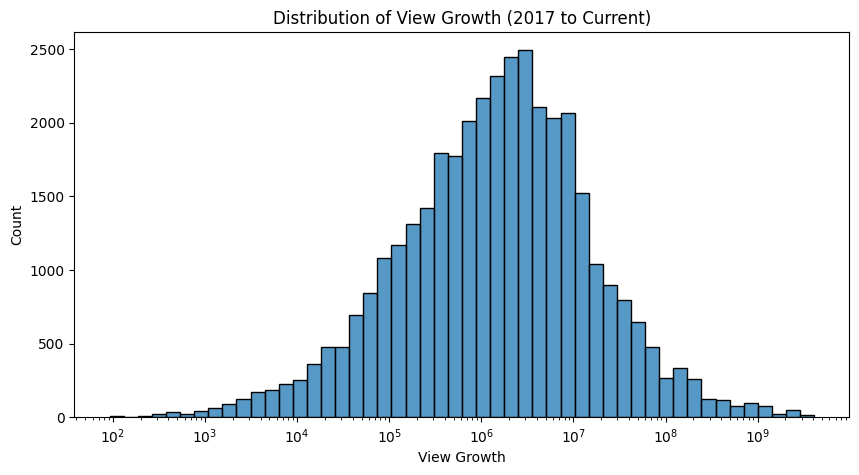

In [ ]:
# EDA on growth: how much have views/likes grown from 2017 to now?

# Growth Analysis
df["view_growth"] = df["views_current"] - df["views_2017"]
df["like_growth"] = df["likes_current"] - df["likes_2017"]
df["comment_growth"] = df["comments_current"] - df["comments_2017"]

print(df[["title", "view_growth", "like_growth", "comment_growth"]].describe())

# Top 10 most grown videos
print(df[["title", "view_growth"]].sort_values("view_growth", ascending=False).head(10))

# Visualize view growth distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["view_growth"], log_scale=True, bins=50)
plt.title("Distribution of View Growth (2017 to Current)")
plt.xlabel("View Growth")
plt.show()


# What we see: 
The average video gained about 22.7 million views since 2017
The median (50%) is 1.6 million — meaning most videos grew modestly, but a few viral videos are pulling the mean way up
Some videos have negative growth (min is -12 million) — this happens when the Kaggle data captured a video at its peak viral moment and views were later removed or the count was corrected by YouTube
Ed Sheeran's "Perfect" and Maroon 5's "Girls Like You" dominate — both gained 4 billion+ views since 2017
You're seeing the same video multiple times because the Kaggle dataset has duplicate rows for videos that trended on multiple days (deduplicating below)

                                                   title  view_growth
58           Ed Sheeran - Perfect (Official Music Video)   4105153487
34367              Maroon 5 - Girls Like You ft. Cardi B   3994240836
534            Luis Fonsi, Demi Lovato - Échame La Culpa   2498719063
28355               Billie Eilish - lovely (with Khalid)   2402904351
27058  Becky G, Natti Natasha - Sin Pijama (Official ...   2312074258
34188  Cardi B, Bad Bunny & J Balvin - I Like It [Off...   1724150407
1976   BTS (방탄소년단) 'MIC Drop (Steve Aoki Remix)' Offi...   1549755992
9563         Calum Scott - You Are The Reason (Official)   1354609004
32207                BTS (방탄소년단) 'FAKE LOVE' Official MV   1339269840
27059               Ariana Grande - No Tears Left To Cry   1285874983


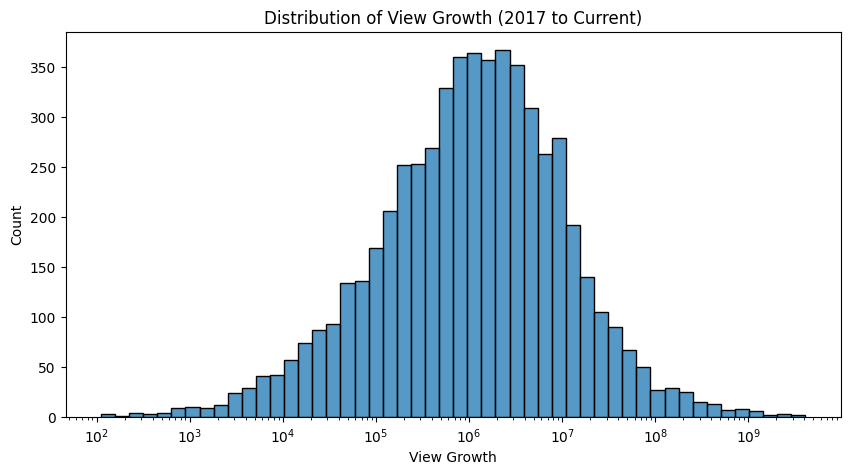

In [55]:
# Deduplicating the videos 
df_unique = df.drop_duplicates(subset="video_id")

print(df_unique[["title", "view_growth"]].sort_values("view_growth", ascending=False).head(10))
plt.figure(figsize=(10, 5))
sns.histplot(df_unique["view_growth"], log_scale=True, bins=50)
plt.title("Distribution of View Growth (2017 to Current)")
plt.xlabel("View Growth")
plt.show()

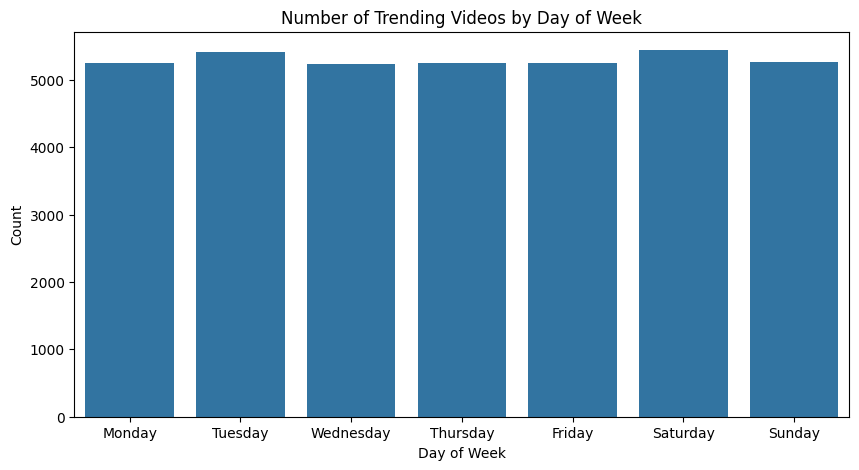

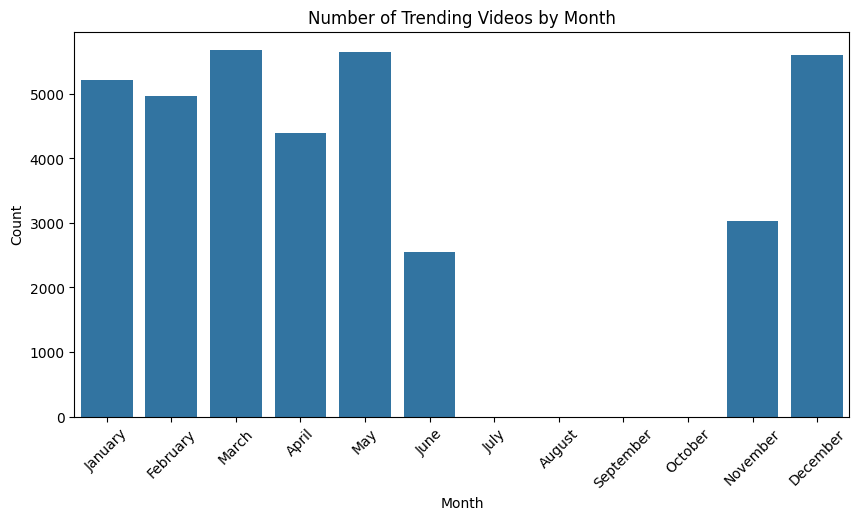

In [56]:
# EDA on trending patterns: what days/months had the most trending videos?

# Trending Patterns
df["day_of_week"] = df["trending_date"].dt.day_name()
df["month"] = df["trending_date"].dt.month_name()

# Videos trending by day of week
plt.figure(figsize=(10, 5))
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.countplot(data=df, x="day_of_week", order=day_order)
plt.title("Number of Trending Videos by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.show()

# Videos trending by month
plt.figure(figsize=(10, 5))
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
sns.countplot(data=df, x="month", order=month_order)
plt.title("Number of Trending Videos by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# What we see:
Day of Week:
Trending videos are almost perfectly evenly distributed across all 7 days — about 5,200-5,400 per day. This means YouTube's trending algorithm doesn't really favor any particular day of the week. Not super interesting but good to know
Month:
This one is more telling. The dataset only covers November 2017 through June 2018 — that's why July through October are completely empty. Within the data you have:

March and May are the peak months (~5,600 trending videos each)
June drops off sharply (~2,500) because the dataset ends partway through June
November is lower (~3,000) because the dataset starts partway through November

So the monthly pattern is mostly reflecting the coverage of the dataset rather than a true seasonal trend. Worth noting that caveat in your project writeup!

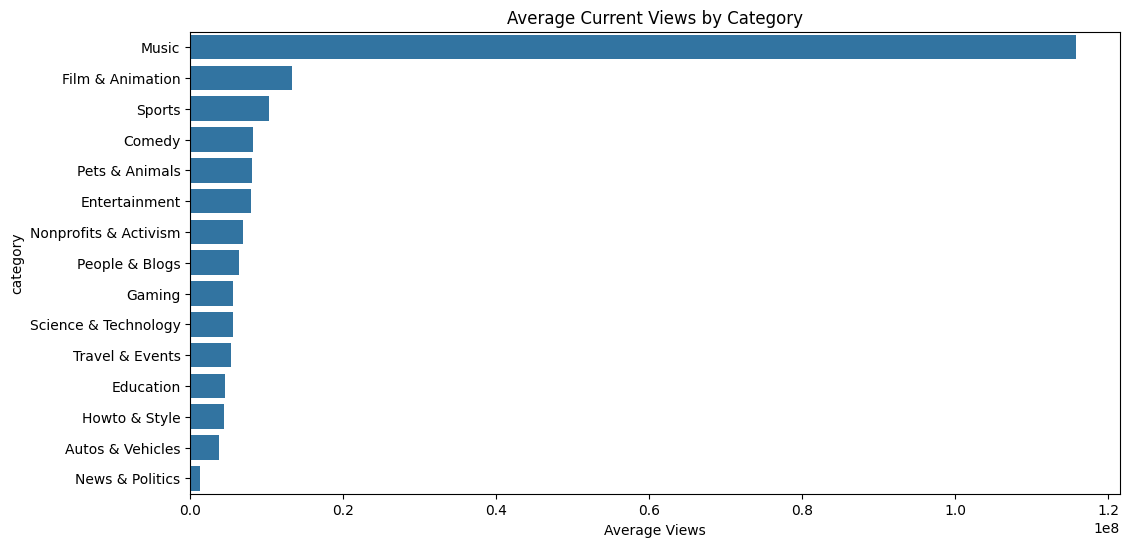

In [57]:
# EDA on Category: which categories get the most views/engagement?

category_map = {
    1: "Film & Animation", 2: "Autos & Vehicles", 10: "Music",
    15: "Pets & Animals", 17: "Sports", 19: "Travel & Events",
    20: "Gaming", 22: "People & Blogs", 23: "Comedy",
    24: "Entertainment", 25: "News & Politics", 26: "Howto & Style",
    27: "Education", 28: "Science & Technology", 29: "Nonprofits & Activism"
}
df["category"] = df["category_id"].map(category_map)

# Views by category
plt.figure(figsize=(12, 6))
cat_views = df.groupby("category")["views_current"].mean().sort_values(ascending=False)
sns.barplot(x=cat_views.values, y=cat_views.index)
plt.title("Average Current Views by Category")
plt.xlabel("Average Views")
plt.show()

# What we see:
Music dominates by a massive margin averaging over 1.1 billion views per video, which is roughly 10x more than the next category (Film & Animation at ~130 million). This makes total sense given what we saw in the growth analysis — the top growers were all music videos like Ed Sheeran and Maroon 5.
The rest of the categories are fairly close to each other, all under 200 million average views. A few interesting notes:

News & Politics is dead last — news videos get views quickly but don't have long term staying power like music does
Sports comes in 3rd which is surprising given it's often considered time-sensitive content
Gaming is lower than you might expect given how big YouTube gaming is

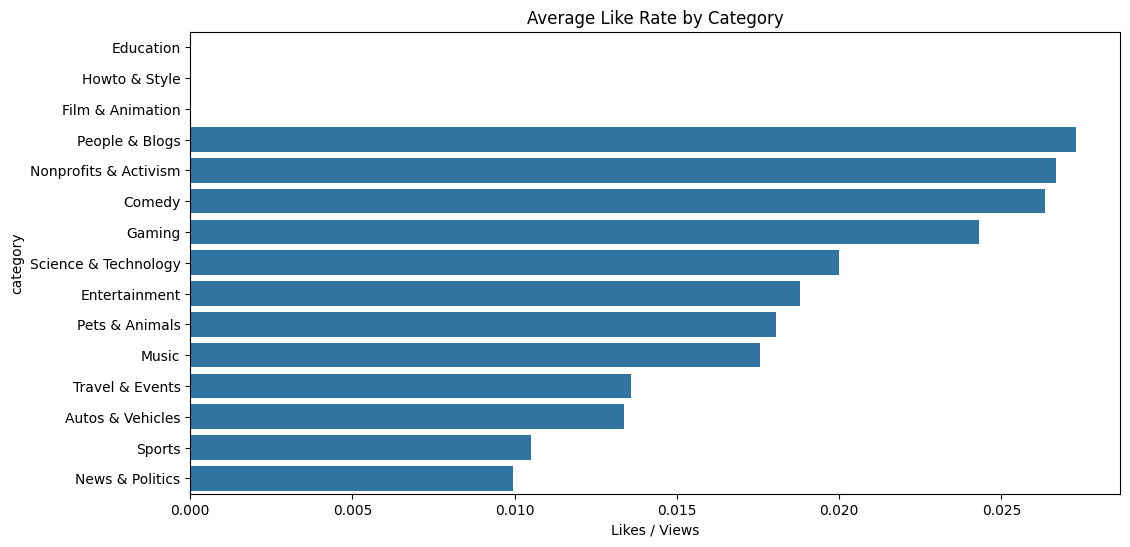

In [59]:
# EDA on engagement: ratio, comment ratio by channel or category?

df_unique["category"] = df_unique["category_id"].map(category_map)
df_unique["like_rate"] = df_unique["likes_current"] / df_unique["views_current"]
df_unique["comment_rate"] = df_unique["comments_current"] / df_unique["views_current"]

# Like rate by category
plt.figure(figsize=(12, 6))
cat_likes = df_unique.groupby("category")["like_rate"].mean().sort_values(ascending=False)
sns.barplot(x=cat_likes.values, y=cat_likes.index)
plt.title("Average Like Rate by Category")
plt.xlabel("Likes / Views")
plt.show()

#What we see: 
Music gets the most views but not the most engagement it sits in the middle for like rate at about 1.8%.
The standouts:
People & Blogs has the highest like rate (~2.8%) — these are personal/creator channels where audiences are highly loyal and engaged
Nonprofits & Activism and Comedy are close behind — content that resonates emotionally drives more active engagement
Education, Howto & Style, and Film & Animation are near zero which looks suspicious — likely a data issue with very few videos in those categories skewing the result
News & Politics and Sports are lowest which makes sense — people watch but don't necessarily like

The key takeaway for your project: views and engagement are different things. Music wins on scale, but smaller creator-driven categories win on audience loyalty.

count    5688.000000
mean       19.874297
std       200.090089
min        -1.000000
25%         0.000000
50%         1.000000
75%         2.000000
max      3562.000000
Name: time_to_trend, dtype: float64


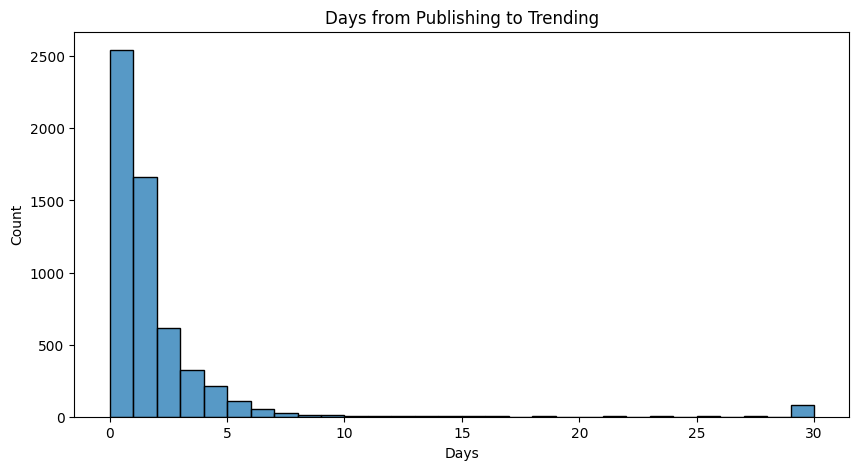

In [60]:
# Time, Trend: how long after publishing does a video start trending

# Time to Trend
df_unique["time_to_trend"] = (df_unique["trending_date"] - df_unique["publish_time"].dt.tz_localize(None)).dt.days

print(df_unique["time_to_trend"].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df_unique["time_to_trend"].clip(0, 30), bins=30)
plt.title("Days from Publishing to Trending")
plt.xlabel("Days")
plt.show()

#What we see: 
Most videos trend within the first 2-3 days of being published, the spike at day 0-1 is huge, meaning YouTube's algorithm picks up viral content almost immediately after upload.
After day 5 it drops off dramatically, and by day 10 almost nothing is trending for the first time.
The small bump at day 30 on the right is an artifact of the .clip(0, 30) — that bar represents all videos that took longer than 30 days to trend, lumped together at the 30 mark. There are a handful of those, likely older videos that got a second life from being referenced or shared.
What did the describe() print? That'll tell us the exact median and mean. But overall the takeaway for your project is: if a video doesn't trend within a week of publishing, it almost certainly won't trend at all.